# 05 grid and friction diagnostics

Three checks that decide how the accessibility calculation is set up, run
before anything is computed on the friction surface.

The first counts how many candidates share a friction cell, which decides the
resolution. The second inspects the friction values themselves for water bodies.
The third confirms that no point sits on a cell with no value.

Nothing is written; the numbers are reported in the methods chapter.

In [1]:
import sys
from pathlib import Path

# config.py sits beside the notebooks, so the working directory is enough. If a
# notebook is run from elsewhere, walk up until it is found.
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "config.py").exists())
sys.path.insert(0, str(ROOT))
from config import *


## 1. Candidate collision

In [2]:
import numpy as np
import pandas as pd
import rasterio
from rasterio import Affine
from rasterio.warp import transform as warp_transform

kc = pd.read_csv(KIKUUBE_CAND)
ks = pd.read_csv(KIKUUBE_SUPPLY)
lon, lat = kc['#lon_deg'].values, kc['#lat_deg'].values
print(f"candidates {len(kc)}, supply {len(ks)}")

candidates 320, supply 1209


Candidates in the same friction cell share a start point and produce identical
cost surfaces, so the optimiser cannot tell them apart. `factor=10` only
subdivides cells arithmetically to show what a 100 m grid would give; it does
not resample anything.

In [3]:
def collisions(path, label, factor=1):
    with rasterio.open(path) as src:
        t = src.transform * Affine.scale(1 / factor, 1 / factor)
        rows, cols = rasterio.transform.rowcol(t, lon, lat)
        rows, cols = np.asarray(rows), np.asarray(cols)
        h, w = src.height * factor, src.width * factor
        res_deg = abs(src.transform.a) / factor
        cx, cy = rasterio.transform.xy(t, rows, cols)

    ok = (rows >= 0) & (rows < h) & (cols >= 0) & (cols < w)
    counts = pd.Series(list(zip(rows[ok], cols[ok]))).value_counts()

    px, py = warp_transform(CRS_GEO, CRS_METRIC, lon[ok].tolist(), lat[ok].tolist())
    qx, qy = warp_transform(CRS_GEO, CRS_METRIC,
                            list(np.asarray(cx)[ok]), list(np.asarray(cy)[ok]))
    disp = np.hypot(np.array(px) - np.array(qx), np.array(py) - np.array(qy))

    colliding = int(counts[counts > 1].sum())
    print(f"\n--- {label}")
    print(f"  cell size            {res_deg:.6f} deg  (~{res_deg * 111320:.0f} m)")
    print(f"  candidates on grid   {int(ok.sum())}")
    print(f"  distinct cells       {len(counts)}")
    print(f"  cells holding >1     {int((counts > 1).sum())}")
    print(f"  candidates colliding {colliding} "
          f"({colliding / ok.sum() * 100:.1f} per cent)")
    print(f"  largest group        {int(counts.max())}")
    print(f"  snap displacement    median {np.median(disp):.0f} m, "
          f"max {disp.max():.0f} m")
    return colliding


native = collisions(FRICTION_TIF, "native friction grid")
fine = collisions(FRICTION_TIF, "same surface split to ~100 m", factor=10)


--- native friction grid
  cell size            0.008333 deg  (~928 m)
  candidates on grid   320
  distinct cells       203
  cells holding >1     47
  candidates colliding 164 (51.2 per cent)
  largest group        18
  snap displacement    median 374 m, max 634 m

--- same surface split to ~100 m
  cell size            0.000833 deg  (~93 m)
  candidates on grid   320
  distinct cells       304
  cells holding >1     10
  candidates colliding 26 (8.1 per cent)
  largest group        5
  snap displacement    median 36 m, max 64 m


Spacing between candidates gives the context for reading those numbers.

In [4]:
xm, ym = warp_transform(CRS_GEO, CRS_METRIC, lon.tolist(), lat.tolist())
pts = np.column_stack([xm, ym])
dm = np.hypot(pts[:, 0][:, None] - pts[:, 0], pts[:, 1][:, None] - pts[:, 1])
np.fill_diagonal(dm, np.inf)
nn = dm.min(axis=1)

print("nearest neighbour spacing, metres")
print(f"  q25 {np.percentile(nn, 25):.0f}   median {np.median(nn):.0f}   "
      f"q75 {np.percentile(nn, 75):.0f}   min {nn.min():.0f}")
print(f"\n{native} of {len(kc)} candidates collide on the native grid, "
      f"{fine} at 100 m.")

nearest neighbour spacing, metres
  q25 170   median 394   q75 1157   min 9

164 of 320 candidates collide on the native grid, 26 at 100 m.


## 2. Friction values

A walking friction surface should be dominated by a single on foot speed. A
second large mode usually means water.

In [5]:
with rasterio.open(FRICTION_TIF) as src:
    f = src.read(1).astype("float64")
    nodata = src.nodata
    print(f"CRS {src.crs} | shape {f.shape} | nodata {nodata}")

if nodata is not None:
    f = np.where(f == nodata, np.nan, f)

valid = f[np.isfinite(f)]
u, c = np.unique(valid, return_counts=True)
order = np.argsort(-c)

print(f"\n{valid.size:,} valid cells, {u.size} distinct values\n")
print(f"{'friction (min/m)':>18}{'cells':>9}{'share':>8}{'km/h':>8}")
for i in order[:6]:
    print(f"{u[i]:18.6f}{c[i]:9d}{c[i] / valid.size * 100:7.1f}%"
          f"{60 / (u[i] * 1000):8.3f}")

CRS EPSG:4326 | shape (69, 116) | nodata None

7,888 valid cells, 1368 distinct values

  friction (min/m)    cells   share    km/h
          0.012000     4002   50.7%   5.000
          0.060000     2437   30.9%   1.000
          0.063093       83    1.1%   0.951
          0.040970        2    0.0%   1.464
          0.041732        1    0.0%   1.438
          0.041794        1    0.0%   1.436


In [6]:
from scipy import ndimage

WATER = 0.060                       # 1 km/h, the usual water body value
water_like = np.isclose(f, WATER, atol=1e-6)
lab, n = ndimage.label(water_like)
sizes = ndimage.sum(water_like, lab, range(1, n + 1))

print(f"cells at the water value {water_like.sum():,} "
      f"({water_like.mean() * 100:.1f} per cent)")
print(f"connected blocks {n}, largest {int(sizes.max()):,} cells "
      f"({sizes.max() / water_like.sum() * 100:.1f} per cent of them)")
print("five largest:", sorted(sizes.astype(int), reverse=True)[:5])

cells at the water value 2,437 (30.4 per cent)
connected blocks 31, largest 1,667 cells (68.4 per cent of them)
five largest: [np.int64(1667), np.int64(560), np.int64(25), np.int64(24), np.int64(22)]


The friction surface and the population surface disagree about where water is.
The size of that disagreement is what matters, so it is measured rather than
assumed away.

In [7]:
with rasterio.open(FRICTION_TIF) as src:
    rr, cc = np.where(water_like)
    xs, ys = rasterio.transform.xy(src.transform, rr, cc)

with rasterio.open(WORLDPOP_TIF) as p:
    vals = np.array([v[0] for v in p.sample(list(zip(xs, ys)))], dtype="float64")
    if p.nodata is not None:
        vals = np.where(vals == p.nodata, 0.0, vals)
vals = np.nan_to_num(vals, nan=0.0)
vals = np.where(vals < 0, 0.0, vals)

print(f"sampled {len(vals):,} water cells")
print(f"  cells carrying population {int((vals > 0).sum()):,}")
print(f"  population on them        {vals.sum():,.0f}")

sampled 2,437 water cells
  cells carrying population 94
  population on them        450


## 3. Points on no data cells

A point on a cell with no friction value cannot seed a cost accumulation and
would drop out silently later.

In [8]:
with rasterio.open(FRICTION_TIF) as src:
    cv = np.array([v[0] for v in src.sample(zip(lon, lat))])
    sv = np.array([v[0] for v in src.sample(
        zip(ks['#lon_deg'], ks['#lat_deg']))])

bad_c = ~np.isfinite(cv)
bad_s = ~np.isfinite(sv)
print(f"candidates on a no data cell: {int(bad_c.sum())}")
print(f"supply points on a no data cell: {int(bad_s.sum())}")
if bad_c.sum():
    print(kc.loc[bad_c, ['#clean_adm4', '#lat_deg', '#lon_deg']].to_string())

candidates on a no data cell: 0
supply points on a no data cell: 0


## 4. Visual check

The friction surface was exported over the district bounding box plus a buffer,
so least cost paths may leave and re enter the district and the surface extends
beyond the boundary.

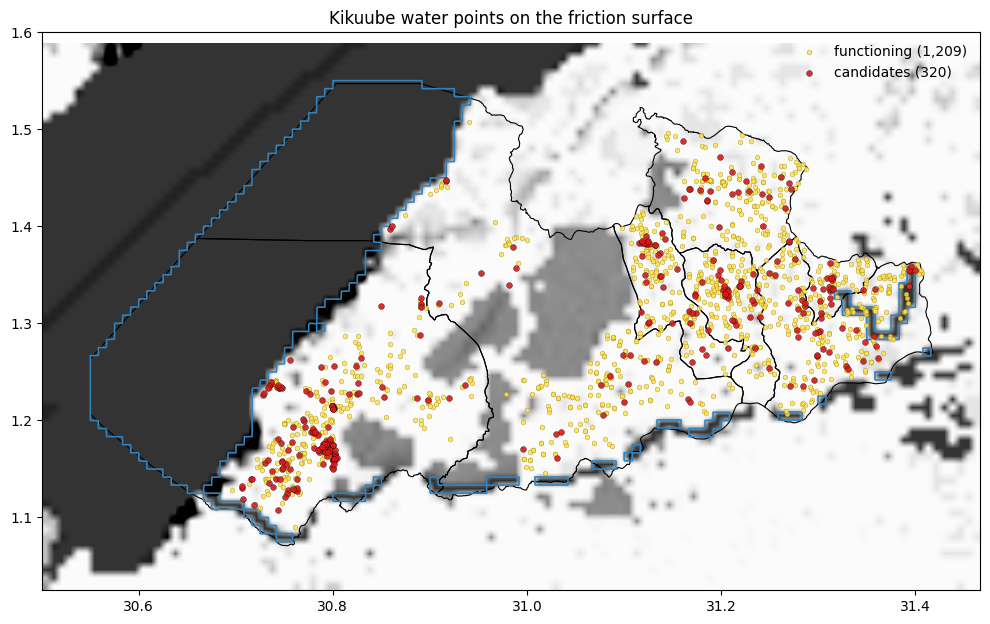

In [9]:
import matplotlib.pyplot as plt
import geopandas as gpd
import numpy as np
import rasterio
from rasterio.mask import mask
from rasterio.features import shapes
from shapely.geometry import shape

sub = gpd.read_file(SUBCOUNTY_GJ).to_crs(CRS_GEO)

with rasterio.open(FRICTION_TIF) as src:
    fr = src.read(1)
    ext = [src.bounds.left, src.bounds.right, src.bounds.bottom, src.bounds.top]

fig, ax = plt.subplots(figsize=(10, 7))

# Bilinear interpolation on the raster display instead of the blocky default,
# which affects rendering only, not the data.
ax.imshow(fr, extent=ext, cmap="Greys", vmin=0.01, vmax=0.07,
          interpolation="bilinear")

# The water polygon is extracted and its outline smoothed with the same
# parameters as the study area figure in 04, so the two read consistently.
with rasterio.open(FRICTION_TIF) as src:
    fr_clip, fr_T = mask(src, sub.dissolve().geometry, crop=True,
                         nodata=np.nan, filled=True)
fr_clip = fr_clip[0]
water_mask = np.isclose(fr_clip, 0.060, atol=0.002).astype("uint8")
polys = [shape(g) for g, v in shapes(water_mask, mask=water_mask.astype(bool),
                                     transform=fr_T) if v == 1]
if polys:
    MIN_AREA_M2 = 50_000     # specks below 5 ha are raster artefacts
    SMOOTH_M = 120           # friction cells are ~93 m

    water_gdf = gpd.GeoDataFrame(geometry=polys, crs=CRS_GEO)
    water_gdf["area_m2"] = water_gdf.to_crs(CRS_METRIC).geometry.area
    water_gdf = water_gdf[water_gdf["area_m2"] > MIN_AREA_M2]

    water_smooth = gpd.GeoDataFrame(
        geometry=[water_gdf.geometry.union_all()], crs=CRS_GEO).to_crs(CRS_METRIC)
    water_smooth["geometry"] = (water_smooth.geometry
                                .buffer(SMOOTH_M).buffer(-SMOOTH_M)
                                .simplify(SMOOTH_M / 3))
    water_smooth = water_smooth.to_crs(CRS_GEO)
    water_smooth.boundary.plot(ax=ax, color="#3182bd", linewidth=1.2, zorder=3)

sub.boundary.plot(ax=ax, color="black", linewidth=0.8, zorder=2)
ax.scatter(ks["#lon_deg"], ks["#lat_deg"], s=14, marker="h", c="#ffe14d",
           edgecolor="#8a7400", linewidth=0.25, alpha=0.85,
           label=f"functioning ({len(ks):,})", zorder=4)
ax.scatter(kc["#lon_deg"], kc["#lat_deg"], s=18, marker="o", c="#d7191c",
           edgecolor="black", linewidth=0.25, alpha=0.9,
           label=f"candidates ({len(kc)})", zorder=5)
ax.legend(loc="upper right", frameon=False)
ax.set_title(f"{DISTRICT} water points on the friction surface")
plt.tight_layout()
plt.savefig(FIG / "05_points_on_friction_smooth.png", dpi=200, bbox_inches="tight")
plt.show()

## What these numbers decide

The collision count settles the grid. Report before going on:

- candidates colliding on the native grid, and the largest group
- nearest neighbour spacing
- the share of cells at the water value, and the population on them
- whether any point sits on a no data cell